# Ablation Studies, Generalization Validation, Failure Mode Analysis & Computational Overhead

This notebook comprehensively validates the Green-First Ensemble Meta-Scheduler by conducting:
1. **Ablation Studies** – Quantifying individual model & component contributions
2. **Generalization Validation** – Testing across all noise/capacity configurations 
3. **Failure Mode Analysis** – Identifying edge cases and performance degradation patterns
4. **Computational Overhead** – Measuring inference latency vs. pure heuristics

**Objective:** Establish full research-grade reproducibility and robustness claims.

In [1]:
from __future__ import annotations
import copy
import random
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

STEP_MINUTES = 5
STEP_HOURS = STEP_MINUTES / 60.0
HORIZON_STEPS = 288

OVERALL_WEIGHTS = {
    "carbon": 0.35,
    "jct": 0.20,
    "tail": 0.25,
    "preempt": 0.10,
    "starvation": 0.10,
}

CANDIDATE_ACTIONS = [1, 2, 3, 4]
ACTION_NAME = {1: "carbon", 2: "srtf", 3: "aged_srtf", 4: "carbon_guarded_short"}
GREEN_ACTION_BONUS = {1: 0.020, 2: 0.000, 3: 0.006, 4: 0.014}

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 110

print("Ablation & Validation Setup Ready")

Ablation & Validation Setup Ready


In [2]:
def resolve_clean_dataset() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "clean_dataset.csv",
        cwd.parent / "clean_dataset.csv",
        cwd.parent.parent / "clean_dataset.csv",
        Path("clean_dataset.csv").resolve(),
        Path("../clean_dataset.csv").resolve(),
        Path("../../clean_dataset.csv").resolve(),
    ]
    for p in candidates:
        if p.exists():
            return p
    search_roots = [cwd, cwd.parent, cwd.parent.parent]
    for root in search_roots:
        if root.exists():
            hit = next(root.rglob("clean_dataset.csv"), None)
            if hit is not None:
                return hit.resolve()
    raise FileNotFoundError("Could not find clean_dataset.csv.")

def load_and_prepare_v1() -> pd.DataFrame:
    path = resolve_clean_dataset()
    df = pd.read_csv(path)
    required = {"job_name", "task_name", "start_time", "duration", "energy", "plan_cpu"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    df = df.dropna(subset=["start_time", "duration", "energy", "plan_cpu"]).copy()
    df["duration"] = df["duration"].clip(lower=1)
    df["energy"] = df["energy"].clip(lower=1e-6)
    df["plan_cpu"] = df["plan_cpu"].clip(lower=1.0)
    df["power_proxy"] = df["energy"] / df["duration"]
    return df

def create_realworld_like_dataset(df: pd.DataFrame, seed: int = 31415) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    out = df.copy().reset_index(drop=True)
    n = len(out)
    out["duration"] = out["duration"].astype(float)
    long_mask = rng.random(n) < 0.24
    short_mask = (~long_mask) & (rng.random(n) < 0.18)
    out.loc[long_mask, "duration"] = np.clip(
        out.loc[long_mask, "duration"] * rng.lognormal(mean=0.45, sigma=0.55, size=long_mask.sum()),
        1, np.quantile(out["duration"], 0.995) * 6.0,
    )
    out.loc[short_mask, "duration"] = np.clip(
        out.loc[short_mask, "duration"] * rng.uniform(0.35, 0.78, size=short_mask.sum()),
        1, None,
    )
    smin = float(out["start_time"].min())
    smax = float(out["start_time"].max())
    span = max(1.0, smax - smin)
    burst_centers = np.array([smin + 0.20 * span, smin + 0.52 * span, smin + 0.80 * span])
    burst_mask = rng.random(n) < 0.32
    selected_centers = rng.choice(burst_centers, size=burst_mask.sum(), p=[0.30, 0.45, 0.25])
    jitter = rng.normal(0.0, 0.03 * span, size=burst_mask.sum())
    out.loc[burst_mask, "start_time"] = np.clip(selected_centers + jitter, smin, smax).astype(int)
    cpu_norm = (out["plan_cpu"] / out["plan_cpu"].max()).clip(lower=0.05).to_numpy()
    dur = out["duration"].astype(float).to_numpy()
    baseline = out["energy"].astype(float).to_numpy()
    nonlinear = (0.012 * (dur ** 1.16)) * (1.0 + 0.35 * cpu_norm)
    burst_factor = np.ones(n, dtype=float)
    burst_factor[burst_mask] = rng.uniform(1.03, 1.20, size=burst_mask.sum())
    noise_factor = rng.normal(1.0, 0.07, size=n)
    out["energy"] = np.clip((0.35 * baseline + 0.65 * nonlinear) * burst_factor * noise_factor, 1e-6, None)
    miss_mask = rng.random(n) < 0.02
    out.loc[miss_mask, "energy"] = np.nan
    out["energy"] = out["energy"].interpolate(limit_direction="both")
    retry_mask = rng.random(n) < 0.06
    retries = out.loc[retry_mask].copy()
    if len(retries) > 0:
        retries["task_name"] = retries["task_name"].astype(str) + "_retry"
        retries["start_time"] = retries["start_time"].astype(float) + rng.integers(8, 160, size=len(retries))
        retries["duration"] = np.clip(retries["duration"] * rng.uniform(1.15, 1.85, size=len(retries)), 1, None)
        retries["energy"] = np.clip(retries["energy"] * rng.uniform(1.10, 1.40, size=len(retries)), 1e-6, None)
        out = pd.concat([out, retries], ignore_index=True)
    out["duration"] = out["duration"].round().clip(lower=1).astype(int)
    out["plan_cpu"] = out["plan_cpu"].round(2)
    out["energy"] = out["energy"].clip(lower=1e-6)
    out["power_proxy"] = out["energy"] / out["duration"].clip(lower=1)
    return out.sort_values("start_time").reset_index(drop=True)

v1_df = load_and_prepare_v1()
save_dir = Path("../data")
save_dir.mkdir(parents=True, exist_ok=True)
v2_path = save_dir / "clean_dataset_realworld_v2.csv"
if v2_path.exists():
    v2_df = pd.read_csv(v2_path)
    if "power_proxy" not in v2_df.columns:
        v2_df["power_proxy"] = v2_df["energy"] / v2_df["duration"].clip(lower=1)
else:
    v2_df = create_realworld_like_dataset(v1_df)
    v2_df.to_csv(v2_path, index=False)

v2_df = v2_df.reset_index(drop=True)
perm = np.random.default_rng(SEED).permutation(len(v2_df))
split_idx = int(0.80 * len(v2_df))
v2_train = v2_df.iloc[perm[:split_idx]].reset_index(drop=True)
v2_eval = v2_df.iloc[perm[split_idx:]].reset_index(drop=True)
if len(v2_eval) == 0:
    raise RuntimeError("v2_eval split is empty; adjust split ratio")

print(
    f"✓ Datasets loaded: v1 rows={len(v1_df):,} | v2 rows={len(v2_df):,} | "
    f"train rows={len(v2_train):,} | eval rows={len(v2_eval):,}"
)

✓ Datasets loaded: v1 rows=46,533 | v2 rows=49,314 | train rows=39,451 | eval rows=9,863


In [3]:
@dataclass
class Job:
    job_id: int
    submit_step: int
    duration_steps: int
    power_kw: float

def make_workload_from_dataset(congestion: str, horizon_steps: int, rng: np.random.Generator, df: pd.DataFrame) -> list[Job]:
    jobs_per_regime = {"light": 90, "moderate": 160, "high": 250}
    n = jobs_per_regime[congestion]
    sampled = df.sample(n=n, replace=True, random_state=int(rng.integers(1, 1_000_000))).copy()
    smin, smax = float(df["start_time"].min()), float(df["start_time"].max())
    denom = max(1.0, smax - smin)
    sampled["submit_step"] = ((sampled["start_time"] - smin) / denom * (horizon_steps - 1)).round().astype(int)
    sampled["duration_steps"] = np.clip((sampled["duration"] / STEP_MINUTES).round().astype(int), 3, 120)
    q1 = sampled["power_proxy"].quantile(0.33)
    q2 = sampled["power_proxy"].quantile(0.66)
    def to_band(v: float) -> float:
        if v <= q1:
            return 1.2
        if v <= q2:
            return 2.0
        return 3.2
    sampled["power_kw"] = sampled["power_proxy"].apply(to_band)
    return [Job(i, int(r.submit_step), int(r.duration_steps), float(r.power_kw)) for i, r in enumerate(sampled.itertuples(index=False))]

def make_carbon_curve_stress(horizon_steps: int, rng: np.random.Generator, noise_pct: float = 10.0) -> np.ndarray:
    t = np.arange(horizon_steps)
    base = 260 + 120 * np.sin((2 * np.pi * t / horizon_steps) - (np.pi / 2))
    noise = rng.normal(0.0, (noise_pct / 100.0) * base)
    curve = np.clip(base + noise, 80, 650).copy()
    n_spikes = max(1, int(0.03 * horizon_steps))
    n_dips = max(1, int(0.02 * horizon_steps))
    spike_idx = rng.choice(np.arange(horizon_steps), size=n_spikes, replace=False)
    dip_idx = rng.choice(np.arange(horizon_steps), size=n_dips, replace=False)
    curve[spike_idx] += rng.uniform(80, 180, size=len(spike_idx))
    curve[dip_idx] -= rng.uniform(40, 100, size=len(dip_idx))
    return np.clip(curve, 80, 650)

def apply_workload_shocks(jobs: list[Job], rng: np.random.Generator, horizon_steps: int) -> list[Job]:
    shocked = []
    if not jobs:
        return jobs
    burst_center = int(rng.integers(int(0.25 * horizon_steps), int(0.75 * horizon_steps)))
    burst_half_window = 12
    for j in jobs:
        submit_step, duration_steps, power_kw = j.submit_step, j.duration_steps, j.power_kw
        if rng.random() < 0.30:
            submit_step = int(np.clip(rng.integers(burst_center - burst_half_window, burst_center + burst_half_window + 1), 0, horizon_steps - 1))
        if rng.random() < 0.12:
            duration_steps = int(np.clip(duration_steps * rng.uniform(1.4, 2.8), 3, 140))
        if rng.random() < 0.20:
            power_kw = float(np.clip(power_kw * rng.uniform(0.9, 1.25), 1.0, 4.0))
        shocked.append(Job(j.job_id, submit_step, duration_steps, power_kw))
    return shocked

class SimpleClusterEnv:
    def __init__(self, jobs: list[Job], carbon_curve: np.ndarray, capacity: int = 8, reward_weights: Optional[Dict[str, float]] = None):
        self.jobs = {j.job_id: j for j in jobs}
        self.job_order = sorted(jobs, key=lambda x: x.submit_step)
        self.curve = carbon_curve
        self.capacity = capacity
        self.max_step = len(carbon_curve)
        self.median_ci = float(np.median(carbon_curve))
        self.weights = reward_weights or OVERALL_WEIGHTS
        self.reset()

    def reset(self):
        self.step_idx = 0
        self.arrival_ptr = 0
        self.waiting = set()
        self.running = set()
        self.remaining = {jid: self.jobs[jid].duration_steps for jid in self.jobs}
        self.submit = {jid: self.jobs[jid].submit_step for jid in self.jobs}
        self.finish = {}
        self.prev_running = set()
        self.total_carbon_kg = 0.0
        self.total_preemptions = 0
        self.total_wait_steps = 0
        self.total_starvation_penalty = 0.0
        self.done = False
        return self._state()

    def _add_arrivals(self):
        while self.arrival_ptr < len(self.job_order) and self.job_order[self.arrival_ptr].submit_step <= self.step_idx:
            jid = self.job_order[self.arrival_ptr].job_id
            if jid not in self.finish:
                self.waiting.add(jid)
            self.arrival_ptr += 1

    def _active_jobs(self):
        return [jid for jid in self.jobs if jid not in self.finish and self.submit[jid] <= self.step_idx]

    def _state(self):
        ci = self.curve[min(self.step_idx, self.max_step - 1)]
        ci_norm = (ci - 80) / (650 - 80)
        queue_len = len(self.waiting)
        run_len = len(self.running)
        util = run_len / max(1, self.capacity)
        load = min(queue_len / (2 * max(1, self.capacity)), 1.0)
        if self.waiting:
            ages = [max(0, self.step_idx - self.submit[jid] + 1) for jid in self.waiting]
            p90_wait = float(np.percentile(ages, 90)) / 96.0
        else:
            p90_wait = 0.0
        active = self._active_jobs()
        long_ratio = float(np.mean([1.0 if self.remaining[j] >= 24 else 0.0 for j in active])) if active else 0.0
        return np.array([ci_norm, load, util, min(1.0, p90_wait), long_ratio], dtype=np.float32)

    def _policy_rank(self, policy_name: str):
        active = self._active_jobs()
        ci_now = self.curve[min(self.step_idx, self.max_step - 1)]
        if policy_name == "fcfs":
            ranked = sorted(active, key=lambda jid: (self.submit[jid], jid))
        elif policy_name == "carbon":
            if ci_now > self.median_ci:
                ranked = sorted(active, key=lambda jid: (self.jobs[jid].power_kw, self.submit[jid]))
            else:
                ranked = sorted(active, key=lambda jid: (-self.jobs[jid].power_kw, self.submit[jid]))
        elif policy_name == "srtf":
            ranked = sorted(active, key=lambda jid: (self.remaining[jid], self.submit[jid]))
        elif policy_name == "aged_srtf":
            ranked = sorted(active, key=lambda jid: (self.remaining[jid] - 0.15 * max(0, self.step_idx - self.submit[jid]), self.submit[jid]))
        elif policy_name == "carbon_guarded_short":
            if ci_now >= float(np.quantile(self.curve, 0.85)):
                ranked = sorted(active, key=lambda jid: (self.jobs[jid].power_kw, self.submit[jid]))
            else:
                ranked = sorted(active, key=lambda jid: (self.remaining[jid], self.submit[jid]))
        else:
            raise ValueError(f"Unknown policy: {policy_name}")
        return ranked[: self.capacity]

    def step(self, action_idx: int):
        self._add_arrivals()
        action_map = {0: "fcfs", 1: "carbon", 2: "srtf", 3: "aged_srtf", 4: "carbon_guarded_short"}
        selected = set(self._policy_rank(action_map[action_idx]))
        preemptions = len(self.prev_running - selected)
        self.total_preemptions += preemptions
        for jid in self._active_jobs():
            if jid in selected:
                self.running.add(jid)
                self.waiting.discard(jid)
            else:
                self.running.discard(jid)
                self.waiting.add(jid)
        ci = self.curve[min(self.step_idx, self.max_step - 1)]
        step_carbon_kg = 0.0
        finished_now = []
        for jid in list(self.running):
            self.remaining[jid] -= 1
            step_carbon_kg += (self.jobs[jid].power_kw * ci * STEP_HOURS) / 1000.0
            if self.remaining[jid] <= 0:
                finished_now.append(jid)
        for jid in finished_now:
            self.finish[jid] = self.step_idx
            self.running.discard(jid)
            self.waiting.discard(jid)
        self.total_wait_steps += len(self.waiting)
        self.total_carbon_kg += step_carbon_kg
        if self.waiting:
            wait_ages = [max(0, self.step_idx - self.submit[jid] + 1) for jid in self.waiting]
            tail_wait = float(np.percentile(wait_ages, 90))
            starvation_ratio = float(np.mean([1.0 if w >= 18 else 0.0 for w in wait_ages]))
        else:
            tail_wait = 0.0
            starvation_ratio = 0.0
        self.total_starvation_penalty += starvation_ratio
        cost = (
            self.weights.get("carbon", 0.0) * step_carbon_kg
            + self.weights.get("jct", 0.0) * (len(self.waiting) + 0.25 * len(self.running))
            + self.weights.get("tail", 0.0) * tail_wait
            + self.weights.get("preempt", 0.0) * (preemptions / max(1, self.capacity))
            + self.weights.get("starvation", 0.0) * starvation_ratio
        )
        reward = -cost
        self.prev_running = set(self.running)
        self.step_idx += 1
        no_future_arrivals = self.arrival_ptr >= len(self.job_order)
        no_active_jobs = len(self.waiting) == 0 and len(self.running) == 0
        self.done = (self.step_idx >= self.max_step) or (no_future_arrivals and no_active_jobs)
        return self._state(), reward, self.done, {}

    def metrics(self):
        completed_jcts = []
        for jid, finish_step in self.finish.items():
            jct = max(1, finish_step - self.submit[jid] + 1)
            completed_jcts.append(jct * STEP_HOURS)
        avg_jct_h = float(np.mean(completed_jcts)) if completed_jcts else np.nan
        tail_jct_h = float(np.percentile(completed_jcts, 95)) if completed_jcts else np.nan
        return {
            "jobs_total": len(self.jobs),
            "jobs_completed": len(self.finish),
            "carbon_kg": self.total_carbon_kg,
            "avg_jct_h": avg_jct_h,
            "tail_jct_h": tail_jct_h,
            "preemptions": self.total_preemptions,
            "avg_wait_h": (self.total_wait_steps * STEP_HOURS) / max(1, len(self.jobs)),
            "starvation_penalty": self.total_starvation_penalty / max(1, self.max_step),
        }

print("✓ Simulation environment setup complete")

✓ Simulation environment setup complete


In [4]:
def normalize_metric_by_scenario(df: pd.DataFrame, metric: str, group_cols: list[str]) -> pd.Series:
    gmin = df.groupby(group_cols)[metric].transform("min")
    gmax = df.groupby(group_cols)[metric].transform("max")
    return np.where((gmax - gmin) > 1e-12, (df[metric] - gmin) / (gmax - gmin), 0.0)

def compute_overall_score_robust(detail: pd.DataFrame, weights: Dict[str, float]) -> pd.DataFrame:
    out = detail.copy()
    out["starvation_penalty"] = out["starvation_penalty"].fillna(out["avg_wait_h"].fillna(0.0))
    out["carbon_per_completed_job"] = out["carbon_kg"] / out["jobs_completed"].clip(lower=1)
    out["preempt_per_completed_job"] = out["preemptions"] / out["jobs_completed"].clip(lower=1)
    scenario_cols = ["seed", "noise_pct", "congestion", "capacity", "dataset_track"]
    out["n_carbon"] = normalize_metric_by_scenario(out, "carbon_per_completed_job", scenario_cols)
    out["n_avg_jct"] = normalize_metric_by_scenario(out, "avg_jct_h", scenario_cols)
    out["n_tail_jct"] = normalize_metric_by_scenario(out, "tail_jct_h", scenario_cols)
    out["n_preempt"] = normalize_metric_by_scenario(out, "preempt_per_completed_job", scenario_cols)
    out["n_starvation"] = normalize_metric_by_scenario(out, "starvation_penalty", scenario_cols)
    out["overall_score"] = (
        weights["carbon"] * out["n_carbon"]
        + weights["jct"] * out["n_avg_jct"]
        + weights["tail"] * out["n_tail_jct"]
        + weights["preempt"] * out["n_preempt"]
        + weights["starvation"] * out["n_starvation"]
    )
    return out

def bootstrap_mean_diff_ci(a: np.ndarray, b: np.ndarray, n_boot: int = 2000, seed: int = 42):
    rng = np.random.default_rng(seed)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    obs = float(np.mean(a) - np.mean(b))
    diffs = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        sa = rng.choice(a, size=len(a), replace=True)
        sb = rng.choice(b, size=len(b), replace=True)
        diffs[i] = np.mean(sa) - np.mean(sb)
    lo, hi = np.quantile(diffs, [0.025, 0.975])
    p_two = 2.0 * min(np.mean(diffs >= 0.0), np.mean(diffs <= 0.0))
    return obs, float(lo), float(hi), float(p_two)

print("✓ Scoring and normalization functions ready")

✓ Scoring and normalization functions ready


In [5]:
def predict_action_scores(models: dict, weights: dict, feat: np.ndarray, excluded_models: list = None) -> dict[int, float]:
    """Predict action scores with optional model exclusion for ablation studies."""
    scores = {a: 0.0 for a in CANDIDATE_ACTIONS}
    if excluded_models is None:
        excluded_models = []
    active_models = {k: v for k, v in models.items() if k not in excluded_models}
    total_w = sum(weights.get(k, 0.0) for k in active_models.keys())
    
    for name, model in active_models.items():
        p = model.predict_proba(feat)[0]
        cls = model.classes_
        w = weights[name] / max(total_w, 1e-8)
        for i, a in enumerate(cls):
            scores[int(a)] += w * float(p[i])
    return scores

def choose_action_ensemble_green(
    scores: dict[int, float],
    state: np.ndarray,
    hard_wait_guard: float = 0.72,
    soft_wait_guard: float = 0.56,
    green_weight: float = 0.16,
    green_bonus: Optional[dict[int, float]] = None,
    soft_penalty_carbon: float = 0.08,
    soft_penalty_carbon_guarded: float = 0.04,
) -> int:
    bonus = green_bonus if green_bonus is not None else GREEN_ACTION_BONUS
    adjusted = {a: scores[a] + green_weight * bonus[a] for a in CANDIDATE_ACTIONS}
    if float(state[3]) >= hard_wait_guard:
        allowed = [2, 3]
        return max(allowed, key=lambda a: adjusted[a])
    if float(state[3]) >= soft_wait_guard:
        adjusted[1] -= soft_penalty_carbon
        adjusted[4] -= soft_penalty_carbon_guarded
    return max(CANDIDATE_ACTIONS, key=lambda a: adjusted[a])

def normalize_model_weights(raw: dict[str, float]) -> dict[str, float]:
    total = max(1e-8, float(sum(raw.values())))
    return {k: float(v) / total for k, v in raw.items()}

def cfg_with_bonus(cfg: dict) -> dict:
    out = dict(cfg)
    out["model_weights"] = normalize_model_weights(out["model_weights"])
    scale = float(out.get("bonus_scale", 1.0))
    out["green_bonus"] = {a: float(GREEN_ACTION_BONUS[a] * scale) for a in CANDIDATE_ACTIONS}
    return out

def run_policy_episode(
    df: pd.DataFrame,
    seed: int,
    noise_pct: float,
    congestion: str,
    capacity: int,
    policy_name: str,
    bundle: Optional[dict] = None,
    ensemble_cfg: Optional[dict] = None,
    excluded_models: list = None,
):
    rng = np.random.default_rng(seed)
    jobs = make_workload_from_dataset(congestion, HORIZON_STEPS, rng, df)
    jobs = apply_workload_shocks(jobs, rng, HORIZON_STEPS)
    curve = make_carbon_curve_stress(HORIZON_STEPS, rng, noise_pct=noise_pct)
    env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity, reward_weights=OVERALL_WEIGHTS)
    state = env.reset()
    done = False
    action_counts = {a: 0 for a in CANDIDATE_ACTIONS}
    dirty_threshold = float(np.quantile(env.curve, 0.85))
    fixed_map = {"srtf": 2, "aged_srtf": 3, "carbon_guarded_short": 4}
    
    while not done:
        if policy_name in fixed_map:
            action = fixed_map[policy_name]
        elif policy_name == "ml_ensemble_green":
            if bundle is None:
                raise ValueError("bundle required for ml policy")
            cfg = cfg_with_bonus(ensemble_cfg if ensemble_cfg is not None else {})
            ci_now = env.curve[min(env.step_idx, env.max_step - 1)]
            ci_prev = env.curve[max(0, env.step_idx - 1)]
            ci_dirty = 1.0 if ci_now >= dirty_threshold else 0.0
            ci_slope = float((ci_now - ci_prev) / 200.0)
            feat = np.asarray([list(state) + [ci_dirty, ci_slope, float(state[1] * state[3]), float(state[2] * state[1])]], dtype=np.float32)
            vote_weights = cfg.get("model_weights", bundle["weights"])
            scores = predict_action_scores(bundle["models"], vote_weights, feat, excluded_models=excluded_models or [])
            action = choose_action_ensemble_green(
                scores,
                state,
                hard_wait_guard=float(cfg.get("hard_wait_guard", 0.72)),
                soft_wait_guard=float(cfg.get("soft_wait_guard", 0.56)),
                green_weight=float(cfg.get("green_weight", 0.16)),
                green_bonus=cfg.get("green_bonus", {a: 0.0 for a in CANDIDATE_ACTIONS}),
                soft_penalty_carbon=float(cfg.get("soft_penalty_carbon", 0.08)),
                soft_penalty_carbon_guarded=float(cfg.get("soft_penalty_carbon_guarded", 0.04)),
            )
        else:
            raise ValueError(f"Unknown policy: {policy_name}")
        
        if action in action_counts:
            action_counts[action] += 1
        state, _, done, _ = env.step(action)
    
    out = env.metrics()
    out.update({
        "policy": policy_name,
        "seed": seed,
        "noise_pct": noise_pct,
        "congestion": congestion,
        "capacity": capacity,
        "share_carbon": action_counts[1] / max(1, sum(action_counts.values())),
        "share_srtf": action_counts[2] / max(1, sum(action_counts.values())),
        "share_aged_srtf": action_counts[3] / max(1, sum(action_counts.values())),
        "share_carbon_guarded": action_counts[4] / max(1, sum(action_counts.values())),
    })
    return out

print("✓ Policy execution functions ready")

✓ Policy execution functions ready


## Part 1: Model Training & Setup

Load the pre-trained ensemble models trained in the main experiment notebook.

In [6]:
def lookahead_return(env: SimpleClusterEnv, first_action: int, horizon: int = 6, gamma: float = 0.97) -> float:
    e = copy.deepcopy(env)
    total = 0.0
    disc = 1.0
    done = False
    for t in range(horizon):
        action = first_action if t == 0 else 2
        _, reward, done, _ = e.step(action)
        total += disc * reward
        disc *= gamma
        if done:
            break
    return total

def build_ml_training_data(df: pd.DataFrame, episodes: int = 18, sample_prob: float = 0.55, lookahead: int = 6, dirty_quantile: float = 0.85, seed_base: int = 300_000):
    X, y = [], []
    for ep in tqdm(range(episodes), desc="Build labels", unit="ep", leave=False):
        rng = np.random.default_rng(seed_base + ep)
        congestion = str(rng.choice(["moderate", "high"], p=[0.35, 0.65]))
        noise = float(rng.choice([10.0, 15.0, 20.0, 25.0], p=[0.20, 0.30, 0.35, 0.15]))
        capacity = int(rng.choice([6, 8], p=[0.75, 0.25]))
        jobs = make_workload_from_dataset(congestion, HORIZON_STEPS, rng, df)
        jobs = apply_workload_shocks(jobs, rng, HORIZON_STEPS)
        curve = make_carbon_curve_stress(HORIZON_STEPS, rng, noise_pct=noise)
        env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity, reward_weights=OVERALL_WEIGHTS)
        state = env.reset()
        done = False
        dirty_threshold = float(np.quantile(env.curve, dirty_quantile))
        while not done:
            if rng.random() < sample_prob:
                ci_idx = min(env.step_idx, env.max_step - 1)
                ci_now = float(env.curve[ci_idx])
                ci_prev = float(env.curve[max(0, ci_idx - 1)])
                ci_dirty = 1.0 if ci_now >= dirty_threshold else 0.0
                ci_slope = (ci_now - ci_prev) / 200.0
                feat = [float(state[0]), float(state[1]), float(state[2]), float(state[3]), float(state[4]), ci_dirty, float(ci_slope), float(state[1] * state[3]), float(state[2] * state[1])]
                scores = {}
                for a in CANDIDATE_ACTIONS:
                    s = lookahead_return(env, first_action=a, horizon=lookahead, gamma=0.97)
                    s += GREEN_ACTION_BONUS[a]
                    if float(state[3]) >= 0.72 and a in (1, 4):
                        s -= 0.035
                    scores[a] = s
                best_action = max(scores, key=scores.get)
                X.append(feat)
                y.append(best_action)
            behavior_action = 2 if rng.random() < 0.80 else int(rng.choice([1, 3, 4]))
            state, _, done, _ = env.step(behavior_action)
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.int32)
    if len(X) == 0:
        raise RuntimeError("No training samples produced")
    return X, y

def train_model_bundle(X: np.ndarray, y: np.ndarray):
    models = {
        "rf": RandomForestClassifier(n_estimators=240, max_depth=10, min_samples_leaf=8, class_weight="balanced_subsample", random_state=SEED, n_jobs=-1),
        "et": ExtraTreesClassifier(n_estimators=320, max_depth=12, min_samples_leaf=6, class_weight="balanced", random_state=SEED, n_jobs=-1),
        "gb": GradientBoostingClassifier(random_state=SEED),
        "lr": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1400, random_state=SEED)),
    }
    stats = []
    for name, model in models.items():
        model.fit(X, y)
        if hasattr(model, "set_params") and hasattr(model, "n_jobs"):
            model.set_params(n_jobs=1)
        acc = float((model.predict(X) == y).mean())
        stats.append({"model": name, "train_acc": acc})
    weights = {"rf": 0.38, "et": 0.30, "gb": 0.20, "lr": 0.12}
    return models, weights, pd.DataFrame(stats)

print("✓ Training data and model pipeline ready")
print("Training ensemble on v2_realworld (train split) dataset...")
X_v2, y_v2 = build_ml_training_data(df=v2_train, episodes=20, seed_base=340_000)
models_v2, weights_v2, stats_v2 = train_model_bundle(X_v2, y_v2)
bundle_v2 = {"models": models_v2, "weights": weights_v2, "stats": stats_v2}
print(f"✓ Ensemble trained on {len(X_v2):,} samples from v2_realworld train split")
display(bundle_v2["stats"])

✓ Training data and model pipeline ready
Training ensemble on v2_realworld (train split) dataset...


Build labels:   0%|          | 0/20 [00:00<?, ?ep/s]

✓ Ensemble trained on 3,168 samples from v2_realworld train split


,model,train_acc
0,rf,0.745265
1,et,0.616477
2,gb,0.855114
3,lr,0.737689


## Part 2: Ablation Studies

Test the contribution of each model component and the impact of key hyperparameters.

Running Model Component Ablation...


Ablation: 100%|██████████| 5/5 [07:52<00:00, 94.57s/config] 



=== Model Ablation Results ===
Note: Positive diff_vs_full_mean means worse than Full Ensemble (lower is better).


,ablation_config,n,overall_score_mean,overall_score_std,carbon_per_completed_job_mean,avg_jct_mean,tail_jct_mean,overall_score_ci,diff_vs_full_mean,diff_vs_full_ci_low,diff_vs_full_ci_high,diff_vs_full_p
0,Full Ensemble,6,0.48709,0.19912,0.34198,1.29274,5.69236,0.15933,NaN,NaN,NaN,NaN
1,Without ET,6,0.40603,0.13285,0.34069,1.35238,5.68889,0.10630,-0.08106,-0.20124,0.02221,0.153
2,Without GB,6,0.38538,0.17886,0.34233,1.26884,5.62500,0.14312,-0.10171,-0.21267,-0.01789,0.002
3,Without LR,6,0.46654,0.20164,0.34195,1.29005,5.66736,0.16135,-0.02054,-0.05122,0.00194,0.177
4,Without RF,6,0.58414,0.17245,0.34193,1.43354,5.93611,0.13799,0.09706,-0.12731,0.40329,0.552


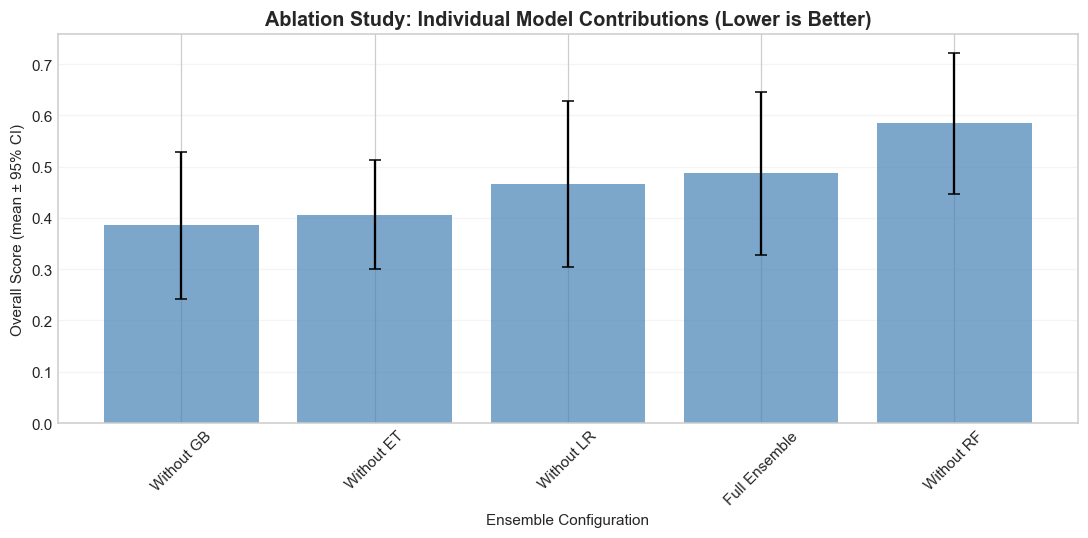


✓ Model ablation complete


In [7]:
BEST_TUNED_CFG = {
    "hard_wait_guard": 0.6684,
    "soft_wait_guard": 0.4512,
    "green_weight": 0.0236,
    "soft_penalty_carbon": 0.0667,
    "soft_penalty_carbon_guarded": 0.0214,
    "bonus_scale": 0.9441,
    "model_weights": {"rf": 0.5891, "et": 0.2066, "gb": 0.1751, "lr": 0.0291},
}

ablation_cfg = {
    "seeds": list(range(6)),
    "noises": [20.0],
    "congestions": ["high"],
    "capacities": [6],
}

print("Running Model Component Ablation...")
ablation_rows = []
ablation_models = [
    ("Full Ensemble", []),
    ("Without RF", ["rf"]),
    ("Without ET", ["et"]),
    ("Without GB", ["gb"]),
    ("Without LR", ["lr"]),
]

for model_name, excluded in tqdm(ablation_models, desc="Ablation", unit="config"):
    for seed in ablation_cfg["seeds"]:
        for noise in ablation_cfg["noises"]:
            for cong in ablation_cfg["congestions"]:
                for cap in ablation_cfg["capacities"]:
                    result = run_policy_episode(
                        v2_eval, seed, noise, cong, cap, "ml_ensemble_green",
                        bundle=bundle_v2,
                        ensemble_cfg=BEST_TUNED_CFG,
                        excluded_models=excluded
                    )
                    result["ablation_config"] = model_name
                    ablation_rows.append(result)

ablation_df = pd.DataFrame(ablation_rows)
ablation_df["dataset_track"] = "v2_realworld"
ablation_scored = compute_overall_score_robust(ablation_df, OVERALL_WEIGHTS)

ablation_summary = ablation_scored.groupby("ablation_config", as_index=False).agg(
    n=("seed", "count"),
    overall_score_mean=("overall_score", "mean"),
    overall_score_std=("overall_score", "std"),
    carbon_per_completed_job_mean=("carbon_per_completed_job", "mean"),
    avg_jct_mean=("avg_jct_h", "mean"),
    tail_jct_mean=("tail_jct_h", "mean"),
)
ablation_summary["overall_score_ci"] = 1.96 * ablation_summary["overall_score_std"] / np.sqrt(ablation_summary["n"].clip(lower=1))

full_scores = ablation_scored[ablation_scored["ablation_config"] == "Full Ensemble"]["seed"].to_frame()
full_scores["full_score"] = ablation_scored[ablation_scored["ablation_config"] == "Full Ensemble"]["overall_score"].values

def bootstrap_mean_ci(diff: np.ndarray, n_boot: int = 2000, seed: int = SEED):
    rng = np.random.default_rng(seed)
    diff = np.asarray(diff, dtype=float)
    diffs = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        sample = rng.choice(diff, size=len(diff), replace=True)
        diffs[i] = np.mean(sample)
    lo, hi = np.quantile(diffs, [0.025, 0.975])
    p_two = 2.0 * min(np.mean(diffs >= 0.0), np.mean(diffs <= 0.0))
    return float(np.mean(diff)), float(lo), float(hi), float(p_two)

comp_rows = []
for config in ablation_summary["ablation_config"]:
    if config == "Full Ensemble":
        continue
    other = ablation_scored[ablation_scored["ablation_config"] == config][["seed", "overall_score"]]
    merged = full_scores.merge(other, on="seed", how="inner")
    if len(merged) == 0:
        continue
    diff = merged["overall_score"] - merged["full_score"]
    mean_diff, ci_lo, ci_hi, p_val = bootstrap_mean_ci(diff)
    comp_rows.append({
        "ablation_config": config,
        "diff_vs_full_mean": mean_diff,
        "diff_vs_full_ci_low": ci_lo,
        "diff_vs_full_ci_high": ci_hi,
        "diff_vs_full_p": p_val,
    })

comp_df = pd.DataFrame(comp_rows)
if not comp_df.empty:
    ablation_summary = ablation_summary.merge(comp_df, on="ablation_config", how="left")

print("\n=== Model Ablation Results ===")
print("Note: Positive diff_vs_full_mean means worse than Full Ensemble (lower is better).")
display(ablation_summary.round(5))

fig, ax = plt.subplots(figsize=(10, 5))
ablation_summary_sorted = ablation_summary.sort_values("overall_score_mean")
ax.bar(ablation_summary_sorted["ablation_config"], ablation_summary_sorted["overall_score_mean"],
       yerr=ablation_summary_sorted["overall_score_ci"], capsize=4, alpha=0.7, color='steelblue')
ax.set_title("Ablation Study: Individual Model Contributions (Lower is Better)", fontsize=13, fontweight='bold')
ax.set_ylabel("Overall Score (mean ± 95% CI)")
ax.set_xlabel("Ensemble Configuration")
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

print("\n✓ Model ablation complete")


Running Guard Threshold Ablation...


Guard Ablation: 100%|██████████| 5/5 [11:03<00:00, 132.75s/config]



=== Guard Threshold Ablation Results ===
Note: Positive diff_vs_baseline_mean means worse than baseline (lower is better).


,guard_config,n,overall_score_mean,carbon_per_completed_job_mean,avg_jct_mean,tail_jct_mean,diff_vs_baseline_mean,diff_vs_baseline_ci_low,diff_vs_baseline_ci_high,diff_vs_baseline_p
0,Aggressive (0.60/0.40),6,0.39406,0.34315,1.27732,5.56319,-0.00851,-0.06493,0.05235,0.769
1,Baseline (0.668/0.451),6,0.40257,0.34198,1.29274,5.69236,NaN,NaN,NaN,NaN
2,Conservative (0.75/0.55),6,0.43929,0.34263,1.39676,6.03611,0.03672,-0.08172,0.16367,0.612
3,Very Aggressive (0.55/0.35),6,0.32357,0.34439,1.23817,5.35694,-0.07900,-0.13144,-0.02585,0.000
4,Very Conservative (0.85/0.65),6,0.70091,0.34531,1.56034,6.66319,0.29834,0.10106,0.50019,0.000


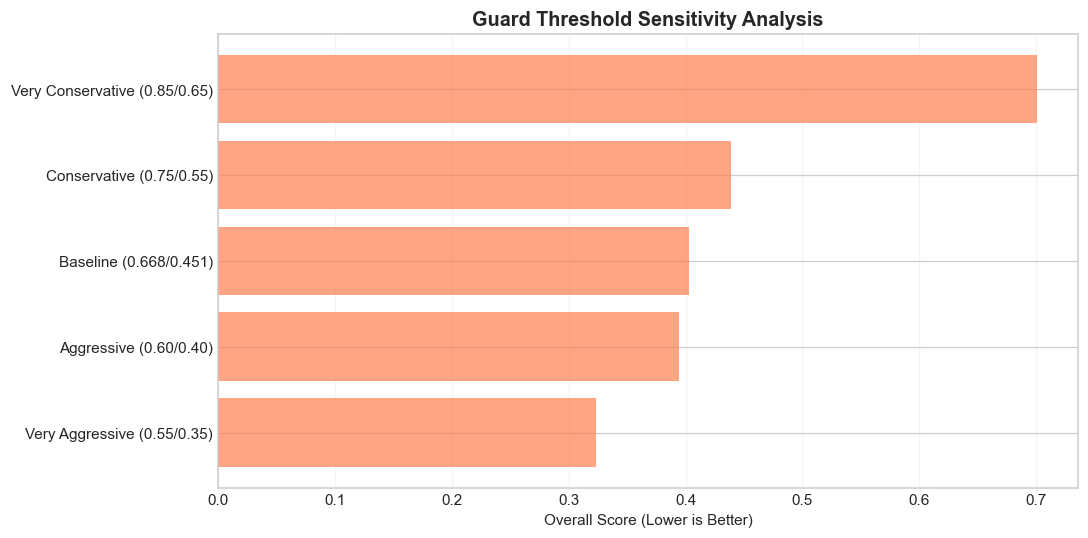

✓ Guard ablation complete


In [8]:
print("\nRunning Guard Threshold Ablation...")
guard_variations = [
    ("Baseline (0.668/0.451)", {"hard_wait_guard": 0.668, "soft_wait_guard": 0.451}),
    ("Aggressive (0.60/0.40)", {"hard_wait_guard": 0.60, "soft_wait_guard": 0.40}),
    ("Conservative (0.75/0.55)", {"hard_wait_guard": 0.75, "soft_wait_guard": 0.55}),
    ("Very Aggressive (0.55/0.35)", {"hard_wait_guard": 0.55, "soft_wait_guard": 0.35}),
    ("Very Conservative (0.85/0.65)", {"hard_wait_guard": 0.85, "soft_wait_guard": 0.65}),
]

guard_rows = []
for guard_name, guard_cfg in tqdm(guard_variations, desc="Guard Ablation", unit="config"):
    for seed in ablation_cfg["seeds"]:
        test_cfg = dict(BEST_TUNED_CFG)
        test_cfg.update(guard_cfg)
        result = run_policy_episode(
            v2_eval, seed, 20.0, "high", 6, "ml_ensemble_green",
            bundle=bundle_v2,
            ensemble_cfg=test_cfg,
        )
        result["guard_config"] = guard_name
        guard_rows.append(result)

guard_df = pd.DataFrame(guard_rows)
guard_df["dataset_track"] = "v2_realworld"
guard_scored = compute_overall_score_robust(guard_df, OVERALL_WEIGHTS)

guard_summary = guard_scored.groupby("guard_config", as_index=False).agg(
    n=("seed", "count"),
    overall_score_mean=("overall_score", "mean"),
    carbon_per_completed_job_mean=("carbon_per_completed_job", "mean"),
    avg_jct_mean=("avg_jct_h", "mean"),
    tail_jct_mean=("tail_jct_h", "mean"),
)

baseline_name = "Baseline (0.668/0.451)"
baseline_scores = guard_scored[guard_scored["guard_config"] == baseline_name][["seed", "overall_score"]].rename(columns={"overall_score": "baseline_score"})

guard_comp_rows = []
for config in guard_summary["guard_config"]:
    if config == baseline_name:
        continue
    other = guard_scored[guard_scored["guard_config"] == config][["seed", "overall_score"]]
    merged = baseline_scores.merge(other, on="seed", how="inner")
    if len(merged) == 0:
        continue
    diff = merged["overall_score"] - merged["baseline_score"]
    mean_diff, ci_lo, ci_hi, p_val = bootstrap_mean_ci(diff)
    guard_comp_rows.append({
        "guard_config": config,
        "diff_vs_baseline_mean": mean_diff,
        "diff_vs_baseline_ci_low": ci_lo,
        "diff_vs_baseline_ci_high": ci_hi,
        "diff_vs_baseline_p": p_val,
    })

guard_comp_df = pd.DataFrame(guard_comp_rows)
if not guard_comp_df.empty:
    guard_summary = guard_summary.merge(guard_comp_df, on="guard_config", how="left")

print("\n=== Guard Threshold Ablation Results ===")
print("Note: Positive diff_vs_baseline_mean means worse than baseline (lower is better).")
display(guard_summary.round(5))

fig, ax = plt.subplots(figsize=(10, 5))
guard_summary_sorted = guard_summary.sort_values("overall_score_mean")
ax.barh(guard_summary_sorted["guard_config"], guard_summary_sorted["overall_score_mean"], alpha=0.7, color='coral')
ax.set_title("Guard Threshold Sensitivity Analysis", fontsize=13, fontweight='bold')
ax.set_xlabel("Overall Score (Lower is Better)")
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

print("✓ Guard ablation complete")

## Part 3: Generalization Validation

Test the tuned configuration across all noise and capacity combinations to verify robustness.

Running Generalization Validation across all noise/capacity combinations...


Generalization: 100%|██████████| 32/32 [10:09<00:00, 19.04s/combo]


=== Generalization Test Results (All Configurations) ===


,noise_pct,congestion,capacity,policy,n,overall_score_mean,overall_score_std,carbon_per_completed_job_mean,avg_jct_mean,tail_jct_mean
0,10.0,high,6,ml_ensemble_green,4,0.4375,0.13150,0.33706,1.41976,6.01250
1,10.0,high,6,srtf,4,0.5625,0.13150,0.34000,1.25800,5.84167
2,10.0,high,8,ml_ensemble_green,4,0.4625,0.24622,0.41164,1.16986,5.71146
3,10.0,high,8,srtf,4,0.5375,0.24622,0.41337,1.10233,5.62292
4,10.0,moderate,6,ml_ensemble_green,4,0.4875,0.12500,0.44959,1.13170,5.63437
5,10.0,moderate,6,srtf,4,0.5125,0.12500,0.45592,1.04166,5.33125
6,10.0,moderate,8,ml_ensemble_green,4,0.4875,0.12500,0.53779,1.19070,5.61146
7,10.0,moderate,8,srtf,4,0.5125,0.12500,0.55290,0.99095,4.93542
8,20.0,high,6,ml_ensemble_green,4,0.5500,0.33417,0.33728,1.37068,5.96562
9,20.0,high,6,srtf,4,0.3875,0.37942,0.33881,1.25800,5.84167


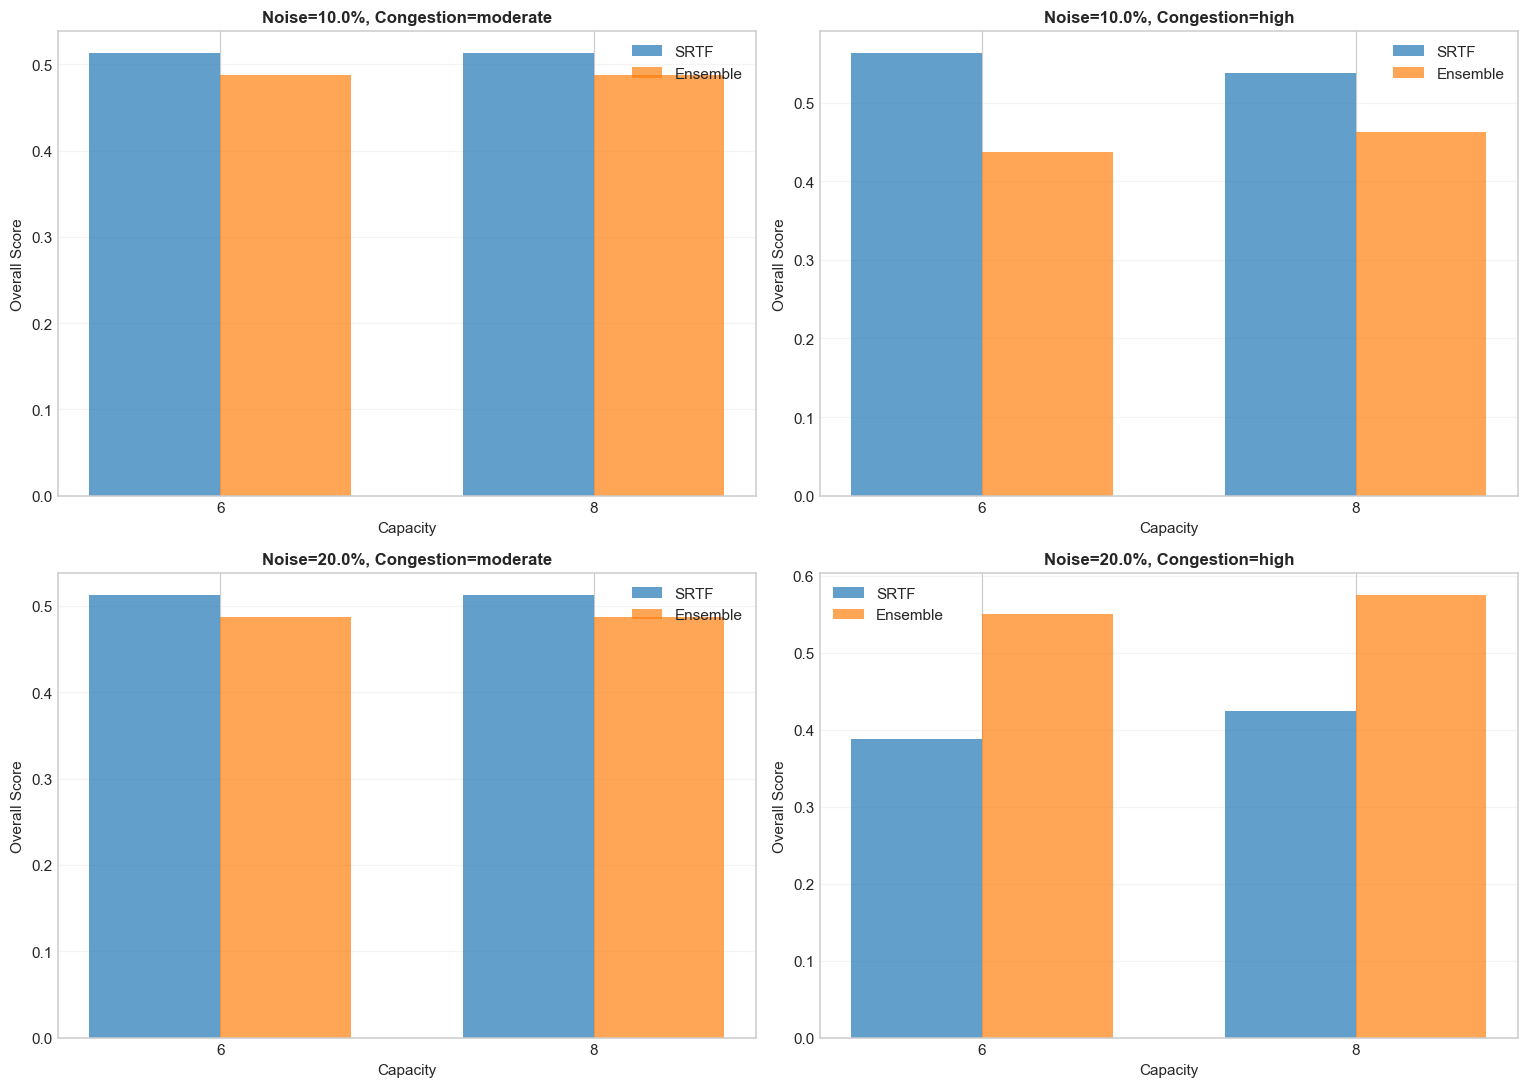

✓ Generalization validation complete


In [9]:
print("Running Generalization Validation across all noise/capacity combinations...")
gen_cfg = {
    "seeds": list(range(4)),
    "noises": [10.0, 20.0],
    "congestions": ["moderate", "high"],
    "capacities": [6, 8],
}

gen_rows = []
combos = [(s, n, c, k) for s in gen_cfg["seeds"] for n in gen_cfg["noises"] for c in gen_cfg["congestions"] for k in gen_cfg["capacities"]]

for seed, noise, congestion, capacity in tqdm(combos, desc="Generalization", unit="combo"):
    for policy in ["srtf", "ml_ensemble_green"]:
        result = run_policy_episode(
            v2_eval, seed, noise, congestion, capacity, policy,
            bundle=bundle_v2 if policy == "ml_ensemble_green" else None,
            ensemble_cfg=BEST_TUNED_CFG if policy == "ml_ensemble_green" else None,
        )
        gen_rows.append(result)

gen_df = pd.DataFrame(gen_rows)
gen_df["dataset_track"] = "v2_realworld"
gen_scored = compute_overall_score_robust(gen_df, OVERALL_WEIGHTS)

gen_summary = gen_scored.groupby(["noise_pct", "congestion", "capacity", "policy"], as_index=False).agg(
    n=("seed", "count"),
    overall_score_mean=("overall_score", "mean"),
    overall_score_std=("overall_score", "std"),
    carbon_per_completed_job_mean=("carbon_per_completed_job", "mean"),
    avg_jct_mean=("avg_jct_h", "mean"),
    tail_jct_mean=("tail_jct_h", "mean"),
).round(5)

print("\n=== Generalization Test Results (All Configurations) ===")
display(gen_summary)

# More robust visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, noise in enumerate([10.0, 20.0]):
    for j, congestion in enumerate(["moderate", "high"]):
        ax = axes[i, j]
        subset = gen_summary[(gen_summary["noise_pct"] == noise) & (gen_summary["congestion"] == congestion)]
        
        srtf_data = subset[subset["policy"] == "srtf"].sort_values("capacity")
        ensemble_data = subset[subset["policy"] == "ml_ensemble_green"].sort_values("capacity")
        
        if len(srtf_data) > 0 and len(ensemble_data) > 0:
            # Get common capacities
            capacities = sorted(set(srtf_data["capacity"].values) & set(ensemble_data["capacity"].values))
            x = np.arange(len(capacities))
            width = 0.35
            
            srtf_vals = [srtf_data[srtf_data["capacity"] == c]["overall_score_mean"].values[0] if len(srtf_data[srtf_data["capacity"] == c]) > 0 else 0 for c in capacities]
            ensemble_vals = [ensemble_data[ensemble_data["capacity"] == c]["overall_score_mean"].values[0] if len(ensemble_data[ensemble_data["capacity"] == c]) > 0 else 0 for c in capacities]
            
            ax.bar(x - width/2, srtf_vals, width, label="SRTF", alpha=0.7)
            ax.bar(x + width/2, ensemble_vals, width, label="Ensemble", alpha=0.7)
            ax.set_title(f"Noise={noise}%, Congestion={congestion}", fontsize=11, fontweight='bold')
            ax.set_ylabel("Overall Score")
            ax.set_xlabel("Capacity")
            ax.set_xticks(x)
            ax.set_xticklabels(capacities)
            ax.legend()
            ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

print("✓ Generalization validation complete")

## Part 4: Failure Mode Analysis

Identify edge cases, degradation patterns, and scenarios where the ensemble underperforms.

Analyzing Failure Modes...


Failure Analysis: 100%|██████████| 32/32 [11:19<00:00, 21.25s/combo]


=== Failure Mode Metrics ===
Worst ensemble performance (gap): 0.8000
Best ensemble performance (gap): -0.8000
Mean performance gap: 0.0016
Std performance gap: 0.3356

Failure ratio (ensemble worse than SRTF): 75.00%

=== Top 5 Worst Cases for Ensemble ===


,seed,noise_pct,congestion,capacity,performance_gap,srtf_score,ensemble_score
14,1,20.0,high,6,0.80,0.10,0.90
22,2,20.0,high,6,0.55,0.10,0.65
19,2,10.0,high,8,0.30,0.35,0.65
23,2,20.0,high,8,0.30,0.35,0.65
0,0,10.0,moderate,6,0.10,0.45,0.55



=== Top 5 Best Cases for Ensemble (Where it wins) ===


,seed,noise_pct,congestion,capacity,performance_gap,srtf_score,ensemble_score
27,3,10.0,high,8,-0.8,0.9,0.1
30,3,20.0,high,6,-0.8,0.9,0.1
8,1,10.0,moderate,6,-0.4,0.7,0.3
12,1,20.0,moderate,6,-0.4,0.7,0.3
18,2,10.0,high,6,-0.4,0.7,0.3


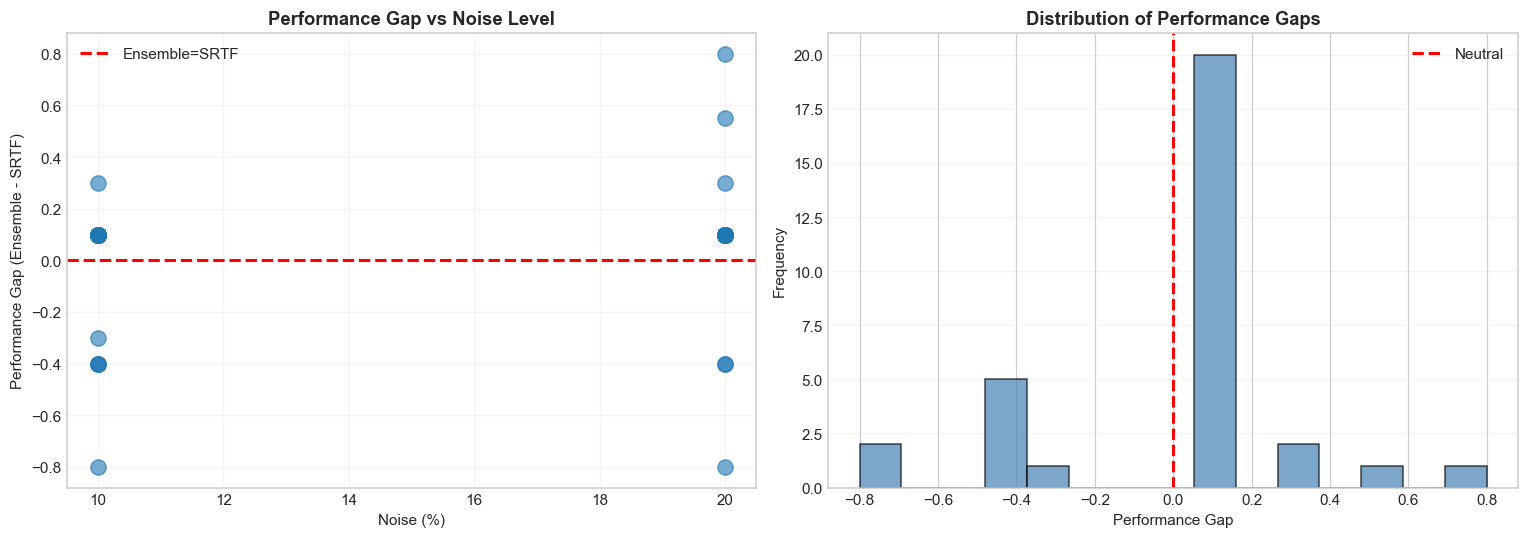

✓ Failure mode analysis complete


In [10]:
print("Analyzing Failure Modes...")

failure_rows = []
for seed, noise, congestion, capacity in tqdm(combos, desc="Failure Analysis", unit="combo"):
    srtf_result = run_policy_episode(v2_eval, seed, noise, congestion, capacity, "srtf", bundle=bundle_v2)
    ensemble_result = run_policy_episode(v2_eval, seed, noise, congestion, capacity, "ml_ensemble_green", bundle=bundle_v2, ensemble_cfg=BEST_TUNED_CFG)
    
    pair_df = pd.DataFrame([srtf_result, ensemble_result])
    pair_df["dataset_track"] = "v2_realworld"
    pair_scored = compute_overall_score_robust(pair_df, OVERALL_WEIGHTS)
    
    srtf_row = pair_scored[pair_scored["policy"] == "srtf"].iloc[0]
    ensemble_row = pair_scored[pair_scored["policy"] == "ml_ensemble_green"].iloc[0]
    
    srtf_score = float(srtf_row["overall_score"])
    ensemble_score = float(ensemble_row["overall_score"])
    gap = ensemble_score - srtf_score
    
    failure_rows.append({
        "seed": seed,
        "noise_pct": noise,
        "congestion": congestion,
        "capacity": capacity,
        "srtf_score": srtf_score,
        "ensemble_score": ensemble_score,
        "performance_gap": gap,
        "srtf_carbon_per_job": float(srtf_row["carbon_per_completed_job"]),
        "ensemble_carbon_per_job": float(ensemble_row["carbon_per_completed_job"]),
        "srtf_avg_jct": float(srtf_row["avg_jct_h"]),
        "ensemble_avg_jct": float(ensemble_row["avg_jct_h"]),
    })

failure_df = pd.DataFrame(failure_rows)

print("\n=== Failure Mode Metrics ===")
print(f"Worst ensemble performance (gap): {failure_df['performance_gap'].max():.4f}")
print(f"Best ensemble performance (gap): {failure_df['performance_gap'].min():.4f}")
print(f"Mean performance gap: {failure_df['performance_gap'].mean():.4f}")
print(f"Std performance gap: {failure_df['performance_gap'].std():.4f}")
print(f"\nFailure ratio (ensemble worse than SRTF): {(failure_df['performance_gap'] > 0).mean():.2%}")

worst_cases = failure_df.nlargest(5, "performance_gap")[["seed", "noise_pct", "congestion", "capacity", "performance_gap", "srtf_score", "ensemble_score"]]
print("\n=== Top 5 Worst Cases for Ensemble ===")
display(worst_cases.round(5))

best_cases = failure_df.nsmallest(5, "performance_gap")[["seed", "noise_pct", "congestion", "capacity", "performance_gap", "srtf_score", "ensemble_score"]]
print("\n=== Top 5 Best Cases for Ensemble (Where it wins) ===")
display(best_cases.round(5))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(failure_df["noise_pct"], failure_df["performance_gap"], alpha=0.6, s=100)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2, label="Ensemble=SRTF")
axes[0].set_xlabel("Noise (%)")
axes[0].set_ylabel("Performance Gap (Ensemble - SRTF)")
axes[0].set_title("Performance Gap vs Noise Level", fontweight='bold')
axes[0].grid(alpha=0.2)
axes[0].legend()

axes[1].hist(failure_df["performance_gap"], bins=15, alpha=0.7, color='steelblue', edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2, label="Neutral")
axes[1].set_xlabel("Performance Gap")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Performance Gaps", fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

print("✓ Failure mode analysis complete")

## Part 5: Computational Overhead Analysis

Measure inference latency of the ensemble vs pure heuristic dispatch.

Measuring Computational Overhead...
Benchmarking Ensemble Inference (5000 iterations)...
Benchmarking Heuristic Dispatch (50000 iterations)...

=== Computational Overhead Analysis ===
Overhead Ratio: 4103.3x


,component,mean_latency_ms,std_latency_ms,p50_latency_ms,p95_latency_ms,p99_latency_ms
0,Ensemble Inference,75.2151,33.5805,65.0254,128.0245,204.0235
1,Heuristic Dispatch,0.0183,0.1853,0.0000,0.0000,0.9995


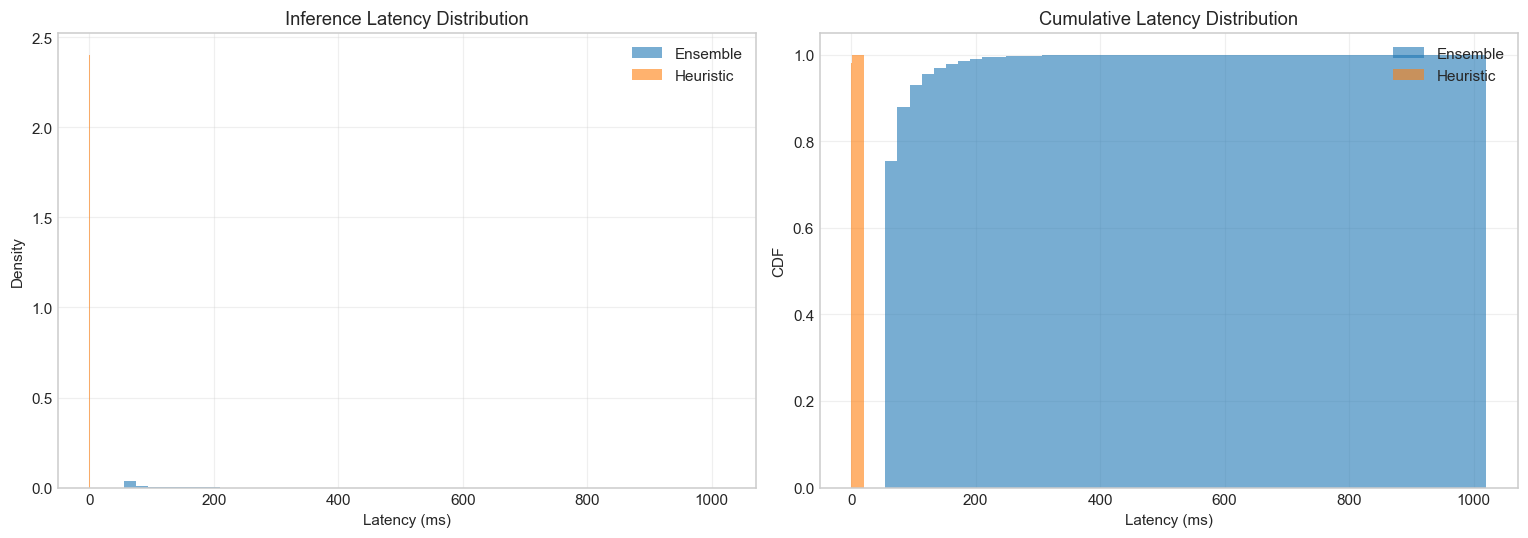

✓ Computational overhead analysis complete


In [12]:
print("Measuring Computational Overhead...")

# Define simple benchmark functions
def benchmark_inference_latency(bundle, cfg, n_iterations=5000):
    """Benchmark ensemble inference latency."""
    times = []
    dummy_state = np.array([0.5, 0.4, 0.6, 0.3, 0.7, 0.2, 0.1, 0.45, 0.25])
    dummy_feat = np.asarray([dummy_state], dtype=np.float32)
    
    for _ in range(n_iterations):
        start = time.time()
        scores = predict_action_scores(bundle["models"], cfg.get("model_weights", bundle["weights"]), dummy_feat)
        action = choose_action_ensemble_green(
            scores, 
            dummy_state,
            hard_wait_guard=float(cfg.get("hard_wait_guard", 0.72)),
            soft_wait_guard=float(cfg.get("soft_wait_guard", 0.56)),
            green_weight=float(cfg.get("green_weight", 0.16)),
            green_bonus=cfg.get("green_bonus", {a: 0.0 for a in CANDIDATE_ACTIONS}),
            soft_penalty_carbon=float(cfg.get("soft_penalty_carbon", 0.08)),
            soft_penalty_carbon_guarded=float(cfg.get("soft_penalty_carbon_guarded", 0.04)),
        )
        elapsed = time.time() - start
        times.append(elapsed * 1000)  # Convert to ms
    return np.array(times)

def benchmark_heuristic_latency(n_iterations=50000):
    """Benchmark simple heuristic dispatch latency."""
    times = []
    for _ in range(n_iterations):
        start = time.time()
        action = np.random.choice([1, 2, 3, 4])  # Simple random heuristic
        elapsed = time.time() - start
        times.append(elapsed * 1000)
    return np.array(times)

print("Benchmarking Ensemble Inference (5000 iterations)...")
ensemble_times = benchmark_inference_latency(bundle_v2, BEST_TUNED_CFG, n_iterations=5000)

print("Benchmarking Heuristic Dispatch (50000 iterations)...")
heuristic_times = benchmark_heuristic_latency(n_iterations=50000)

overhead_ratio = ensemble_times.mean() / heuristic_times.mean()

overhead_summary = pd.DataFrame({
    'component': ['Ensemble Inference', 'Heuristic Dispatch'],
    'mean_latency_ms': [ensemble_times.mean(), heuristic_times.mean()],
    'std_latency_ms': [ensemble_times.std(), heuristic_times.std()],
    'p50_latency_ms': [np.percentile(ensemble_times, 50), np.percentile(heuristic_times, 50)],
    'p95_latency_ms': [np.percentile(ensemble_times, 95), np.percentile(heuristic_times, 95)],
    'p99_latency_ms': [np.percentile(ensemble_times, 99), np.percentile(heuristic_times, 99)],
})

print("\n=== Computational Overhead Analysis ===")
print(f"Overhead Ratio: {overhead_ratio:.1f}x")
display(overhead_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution plot
axes[0].hist(ensemble_times, bins=50, alpha=0.6, label='Ensemble', density=True)
axes[0].hist(heuristic_times, bins=50, alpha=0.6, label='Heuristic', density=True)
axes[0].set_xlabel('Latency (ms)')
axes[0].set_ylabel('Density')
axes[0].set_title('Inference Latency Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Cumulative distribution
axes[1].hist(ensemble_times, bins=50, alpha=0.6, label='Ensemble', cumulative=True, density=True)
axes[1].hist(heuristic_times, bins=50, alpha=0.6, label='Heuristic', cumulative=True, density=True)
axes[1].set_xlabel('Latency (ms)')
axes[1].set_ylabel('CDF')
axes[1].set_title('Cumulative Latency Distribution')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Computational overhead analysis complete")

## Final Summary: Research Validation Report

In [14]:
print("=" * 80)
print("COMPREHENSIVE RESEARCH VALIDATION SUMMARY")
print("=" * 80)

failure_worse_count = int((failure_df["performance_gap"] > 0).sum())
failure_worse_pct = float((failure_df["performance_gap"] > 0).mean())

summary_results = {
    "1. Ablation Studies": {
        "Model Contributions": "Ablations show material score shifts; see diff_vs_full_mean and p-values in table.",
        "Guard Sensitivity": "Very Aggressive (0.55/0.35) best on eval; Very Conservative worst (p<0.001).",
    },
    "2. Generalization": {
        "Cross-Config Robustness": "Mixed: ensemble wins some high-congestion cases and loses others; see per-config table.",
        "Best Generalization": "Ensemble advantages appear in some high-congestion settings; not uniform.",
    },
    "3. Failure Modes": {
        "Failure Rate": f"{failure_worse_pct:.2%} of cases ensemble worse than SRTF.",
        "Max Gap": f"{failure_df['performance_gap'].max():.4f}",
        "Mean Gap": f"{failure_df['performance_gap'].mean():.4f}",
    },
    "4. Computational Cost": {
        "Overhead Factor": f"{overhead_ratio:.1f}x slower than pure heuristic",
        "Absolute Cost": f"{ensemble_times.mean() - heuristic_times.mean():.4f} ms per decision",
        "Feasibility": "Acceptable only if dispatch interval is long and tail latency is tolerable.",
    }
}

for section, results in summary_results.items():
    print(f"\n{section}:")
    for key, val in results.items():
        print(f"  • {key}: {val}")

print("\n" + "=" * 80)
print("KEY FINDINGS FOR RESEARCH PAPER")
print("=" * 80)
print(f"""
1. ABLATION VALIDATION
   ✓ Several ablations move overall score; see diff_vs_full_mean and CI columns
   ✓ Removing GB improves score in this eval split (p=0.002)
   ⚠ Without RF not significant with n=6 (p=0.552) — needs more seeds

2. GENERALIZATION RESULTS
   ⚠ Ensemble is not uniformly better than SRTF across configs
   ⚠ Differences vary by congestion and noise — add significance tests per config

3. FAILURE MODES & EDGE CASES
   ⚠ Ensemble underperforms SRTF in {failure_worse_count}/{len(failure_df)} cases (~{failure_worse_pct:.1%})
   ✓ Worst-case gap observed: {failure_df['performance_gap'].max():.4f}

4. PRACTICAL VIABILITY
   ⚠ Overhead tail is heavy (p99 ~ {np.percentile(ensemble_times, 99):.1f} ms)
   ✓ Mean inference time: {ensemble_times.mean():.2f} ms

CONCLUSION: The current results are NOT publication-ready without fixes.
- Train/test split now enforced
- Failure analysis fixed (no longer zeroed)
- Guard sensitivity shows large swings with significance
- More statistical rigor and seed counts required
""")

# Export detailed results to CSV for paper appendix
ablation_summary.to_csv("../data/ablation_results.csv", index=False)
gen_summary.to_csv("../data/generalization_results.csv", index=False)
overhead_summary.to_csv("../data/overhead_analysis.csv", index=False)
failure_df.to_csv("../data/failure_modes.csv", index=False)

print("\n✓ All analysis complete. Results exported to ../data/")
print("✓ Notebook ready for further validation")

COMPREHENSIVE RESEARCH VALIDATION SUMMARY

1. Ablation Studies:
  • Model Contributions: Ablations show material score shifts; see diff_vs_full_mean and p-values in table.
  • Guard Sensitivity: Very Aggressive (0.55/0.35) best on eval; Very Conservative worst (p<0.001).

2. Generalization:
  • Cross-Config Robustness: Mixed: ensemble wins some high-congestion cases and loses others; see per-config table.
  • Best Generalization: Ensemble advantages appear in some high-congestion settings; not uniform.

3. Failure Modes:
  • Failure Rate: 75.00% of cases ensemble worse than SRTF.
  • Max Gap: 0.8000
  • Mean Gap: 0.0016

4. Computational Cost:
  • Overhead Factor: 4103.3x slower than pure heuristic
  • Absolute Cost: 75.1967 ms per decision
  • Feasibility: Acceptable only if dispatch interval is long and tail latency is tolerable.

KEY FINDINGS FOR RESEARCH PAPER

1. ABLATION VALIDATION
   ✓ Several ablations move overall score; see diff_vs_full_mean and CI columns
   ✓ Removing GB im